# Event Study Panel Construction

This notebook demonstrates building DiD panels for climate event studies using three approaches:

1. **Multi-Event Panel** (de Chaisemartin & d'Haultfœuille, 2020): Firms can experience multiple events
2. **Staggered Panel** (Sun & Abraham, 2021): First-event timing with not-yet-treated control
3. **Stacked Cohort** (Roth et al., 2022): Clean 2×2 comparisons by cohort

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Add paths
NOTEBOOK_DIR = os.path.join(os.getcwd(), "data-preparation")
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

DATA_DIR = os.path.join(os.getcwd(), "data")

# --- NEW: did-panel-builder ---
from did_panel_builder import (
    MultiEventPanel,
    PanelConfig,
    StackedPanel,
    StaggeredPanel,
    TreatmentAssigner,
)
from did_panel_builder.diagnostics import CoverageAnalyzer, PrePostDiagnostics
from did_panel_builder.visualization import (
    plot_by_treatment_status,
    plot_coverage_summary,
    plot_location_events,
    plot_multi_outcome,
    plot_pre_post_coverage,
    plot_treatment_distribution,
    plot_treatment_funnel,
    plot_treatment_summary,
)

# Domain-specific modules (not migrated — project-specific)
from climate_study import SheldusTreatmentBuilder
from climate_study.visualization import LocationVisualizer

# Panel configuration (shared across all panel builders)
config = PanelConfig(unit_col="cik", time_col="year", event_col="has_event")

In [2]:
pd.set_option("max_colwidth", None)
pd.set_option('display.max_columns', None)

## Load Industry Data

Query firm-industry mappings from Neo4j graph. Each firm is linked to an Industry node via the `IN_INDUSTRY` relationship, with SIC codes (4-digit and 2-digit).

In [3]:
df_industry = pd.read_parquet(os.path.join(DATA_DIR, "df_industry.parquet"))

In [48]:
df_industry.head()

,cik,company_name,sic,sic2
0,1000045,NICHOLAS FINANCIAL INC,6153,61
1,1000180,SANDISK CORP,3572,35
2,1000209,MEDALLION FINANCIAL CORP,6199,61
3,1000227,TB WOOD'S CORP,3569,35
4,1000228,HENRY SCHEIN INC,5047,50


## Load Financial Data

# Compustat Variables – Definitions

## 1. Identifiers and Time

| Variable | Definition |
|-----------|------------|
| `cik` | Central Index Key; unique firm identifier assigned by the SEC. |
| `year` | Fiscal year of the observation. |
| `period_end_date` | Fiscal period end date. |


## 2. Revenue and Income Statement Variables

| Variable | Definition |
|-----------|------------|
| `revenue` | Total revenues reported by the firm. |
| `sales` | Net sales (often used interchangeably with revenue). |
| `net_income` | Net income after taxes and extraordinary items. |
| `income_before_extra` | Income before extraordinary items. |
| `pretax_income` | Earnings before income taxes. |
| `ebit` | Earnings before interest and taxes. |
| `ebitda` | Earnings before interest, taxes, depreciation, and amortization. |
| `operating_income_bd` | Operating income before depreciation. |
| `operating_income_ad` | Operating income after depreciation. |
| `gross_profit` | Revenue minus cost of goods sold. |
| `cost_of_goods_sold` | Direct costs attributable to production of goods sold. |
| `rd_expense` | Research and development expenses. |
| `sga_expense` | Selling, general, and administrative expenses. |
| `advertising_expense` | Advertising expenditures. |
| `interest_expense` | Interest paid on debt. |
| `depreciation` | Depreciation and amortization expense. |
| `special_items` | One-time or non-recurring items affecting earnings. |
| `writedowns_pretax` | Asset writedowns before taxes. |
| `goodwill_impairment` | Impairment charges related to goodwill. |
| `restructuring_costs` | Costs related to restructuring activities. |
| `income_tax` | Income tax expense. |
| `stock_compensation` | Expense related to stock-based compensation. |

## 3. Balance Sheet Variables

| Variable | Definition |
|-----------|------------|
| `total_assets` | Total assets of the firm. |
| `ppe_net` | Net property, plant, and equipment. |
| `ppe_gross` | Gross property, plant, and equipment. |
| `intangibles` | Intangible assets excluding goodwill. |
| `goodwill` | Goodwill recorded on the balance sheet. |
| `inventories` | Inventory holdings. |
| `receivables` | Accounts receivable. |
| `cash` | Cash and cash equivalents. |
| `current_assets` | Assets expected to be converted into cash within one year. |
| `total_liabilities` | Total liabilities. |
| `long_term_debt` | Debt obligations due after one year. |
| `current_debt` | Short-term debt obligations. |
| `current_liabilities` | Liabilities due within one year. |
| `common_equity` | Book value of common equity. |
| `stockholders_equity` | Total shareholders’ equity. |
| `working_capital` | Current assets minus current liabilities. |

---

## 4. Market Variables

| Variable | Definition |
|-----------|------------|
| `market_value` | Market capitalization of the firm. |
| `shares_outstanding` | Number of common shares outstanding. |
| `price_close` | Closing stock price at fiscal year end. |
| `log_mkvalt` | Logarithm of market value. |
| `ln_market_value` | Natural logarithm of market value. |


## 5. Cash Flow Variables

| Variable | Definition |
|-----------|------------|
| `operating_cashflow` | Net cash flow from operating activities. |
| `investing_cashflow` | Net cash flow from investing activities. |
| `financing_cashflow` | Net cash flow from financing activities. |
| `dividends` | Dividends paid to shareholders. |
| `dividends_total` | Total dividends paid (may include preferred dividends). |
| `stock_repurchase` | Expenditures on share repurchases. |
| `capex` | Capital expenditures. |


## 6. Size and Employment

| Variable | Definition |
|-----------|------------|
| `employees` | Number of employees. |
| `log_assets` | Logarithm of total assets. |
| `log_revenue` | Logarithm of revenue. |

## 7. Financial Ratios and Constructed Variables

| Variable | Definition |
|-----------|------------|
| `leverage` | Ratio of total debt to total assets (or similar debt measure). |
| `roa` | Return on assets (net income divided by total assets). |
| `asset_tangibility` | Ratio of tangible assets (e.g., PPE) to total assets. |
| `rd_intensity` | R&D expenses divided by revenue or assets. |
| `cash_ratio` | Cash divided by total assets or current liabilities. |
| `capex_intensity` | Capital expenditures divided by total assets or revenue. |
| `intangibility` | Ratio of intangible assets to total assets. |
| `current_ratio` | Current assets divided by current liabilities. |
| `debt_to_equity` | Total debt divided by shareholders’ equity. |
| `gross_margin` | Gross profit divided by revenue. |
| `operating_margin` | Operating income divided by revenue. |

In [4]:
df_financial = (
    pd.read_parquet(os.path.join(DATA_DIR, "df_financial.parquet"))
    .assign(
        ln_market_value=lambda x: np.log(x["market_value"] + 1)
    )
)

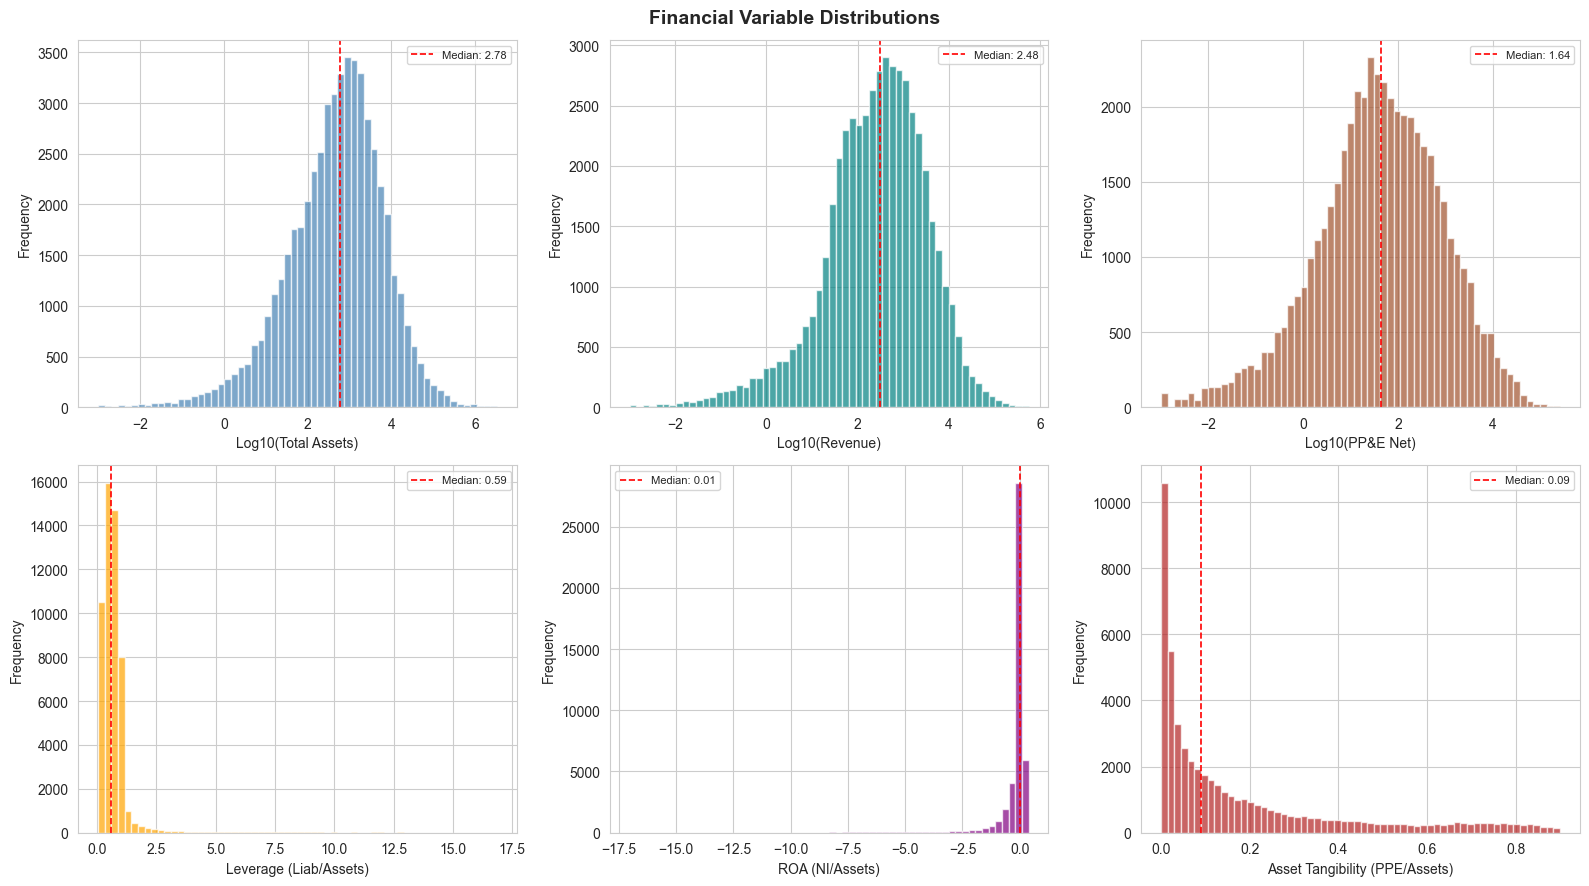

In [5]:
# Distributions of key financial variables (2x3)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_specs = [
    ('total_assets', 'Log10(Total Assets)', True, 'steelblue'),
    ('revenue', 'Log10(Revenue)', True, 'teal'),
    ('ppe_net', 'Log10(PP&E Net)', True, 'sienna'),
    ('leverage', 'Leverage (Liab/Assets)', False, 'orange'),
    ('roa', 'ROA (NI/Assets)', False, 'purple'),
    ('asset_tangibility', 'Asset Tangibility (PPE/Assets)', False, 'firebrick'),
]

for ax, (col, xlabel, use_log, color) in zip(axes.flat, plot_specs):
    valid = df_financial[col].dropna()
    if use_log:
        valid = valid[valid > 0]
        data = np.log10(valid)
    else:
        lo, hi = valid.quantile(0.01), valid.quantile(0.99)
        data = valid[(valid >= lo) & (valid <= hi)]
    ax.hist(data, bins=60, edgecolor='white', alpha=0.7, color=color)
    ax.axvline(data.median(), color='red', ls='--', lw=1.2, label=f'Median: {data.median():.2f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Financial Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

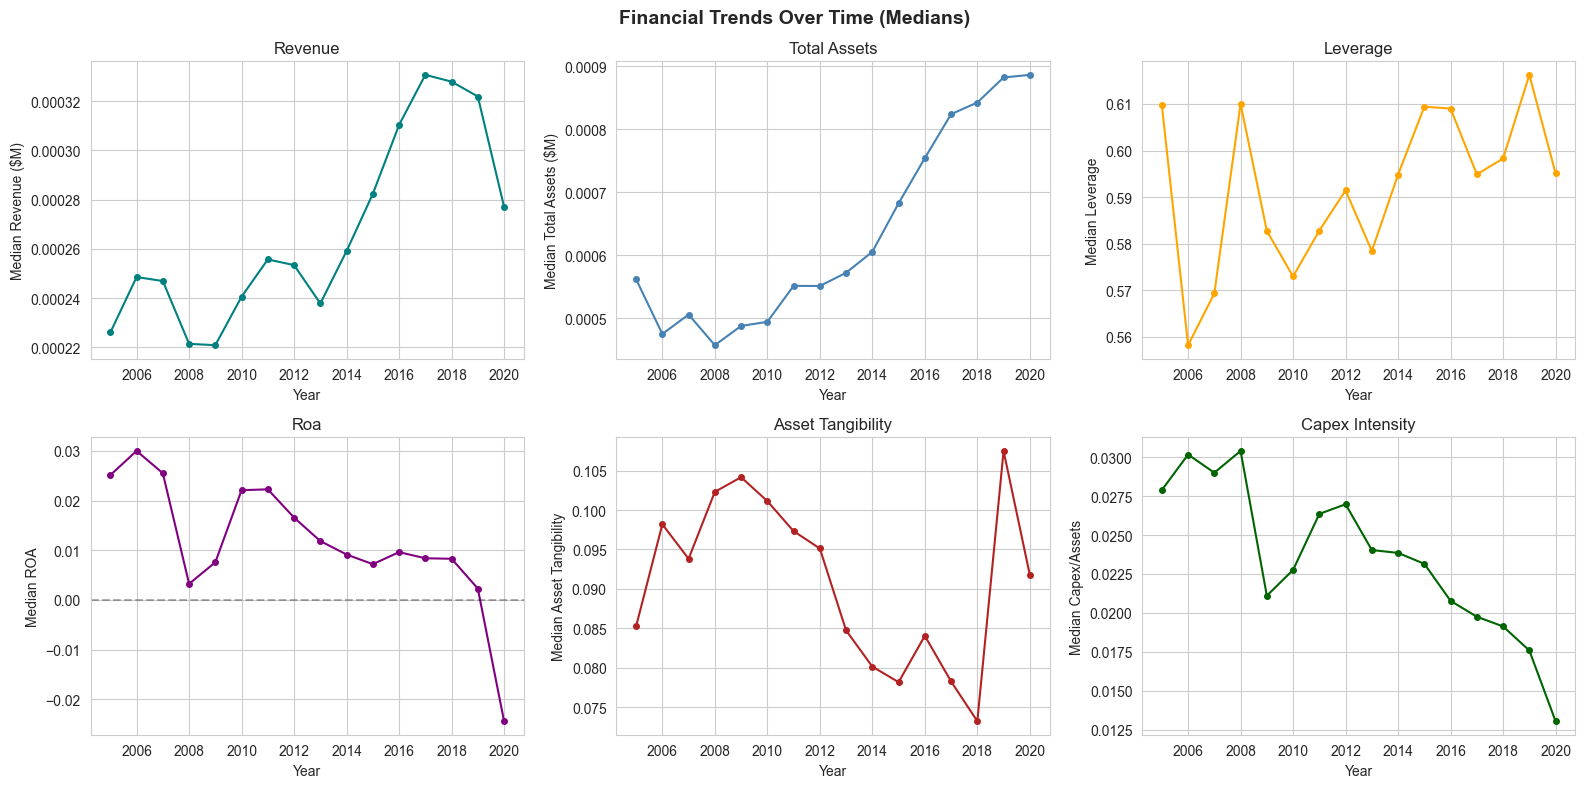

In [6]:
# Median trends over time (2x3)
trend_vars = [
    ('revenue', 'Median Revenue ($M)', 1e6, 'teal'),
    ('total_assets', 'Median Total Assets ($M)', 1e6, 'steelblue'),
    ('leverage', 'Median Leverage', 1, 'orange'),
    ('roa', 'Median ROA', 1, 'purple'),
    ('asset_tangibility', 'Median Asset Tangibility', 1, 'firebrick'),
    ('capex_intensity', 'Median Capex/Assets', 1, 'darkgreen'),
]

yearly = df_financial.groupby('year')[
    [v[0] for v in trend_vars]
].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, ylabel, divisor, color) in zip(axes.flat, trend_vars):
    ax.plot(yearly['year'], yearly[col] / divisor, marker='o', ms=4, color=color)
    if col == 'roa':
        ax.axhline(0, color='black', ls='--', alpha=0.3)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(col.replace('_', ' ').title())

plt.suptitle('Financial Trends Over Time (Medians)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

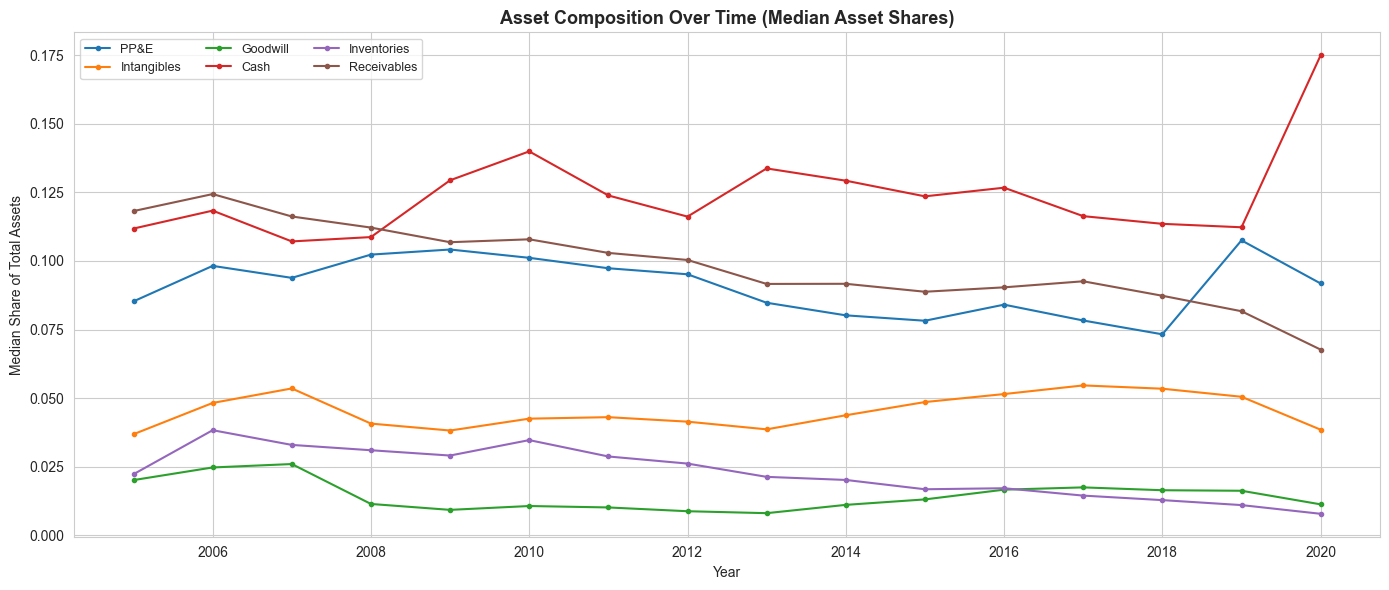

In [7]:
# Asset composition: median shares over time
composition_vars = {
    'ppe_net': 'PP&E',
    'intangibles': 'Intangibles',
    'goodwill': 'Goodwill',
    'cash': 'Cash',
    'inventories': 'Inventories',
    'receivables': 'Receivables',
}

fig, ax = plt.subplots(figsize=(14, 6))
yearly_comp = df_financial.copy()
for col in composition_vars:
    yearly_comp[f'{col}_share'] = yearly_comp[col] / yearly_comp['total_assets']

share_cols = [f'{c}_share' for c in composition_vars]
yearly_shares = yearly_comp.groupby('year')[share_cols].median().reset_index()

for col, label in composition_vars.items():
    ax.plot(yearly_shares['year'], yearly_shares[f'{col}_share'], marker='o', ms=3, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('Median Share of Total Assets')
ax.set_title('Asset Composition Over Time (Median Asset Shares)', fontsize=13, fontweight='bold')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

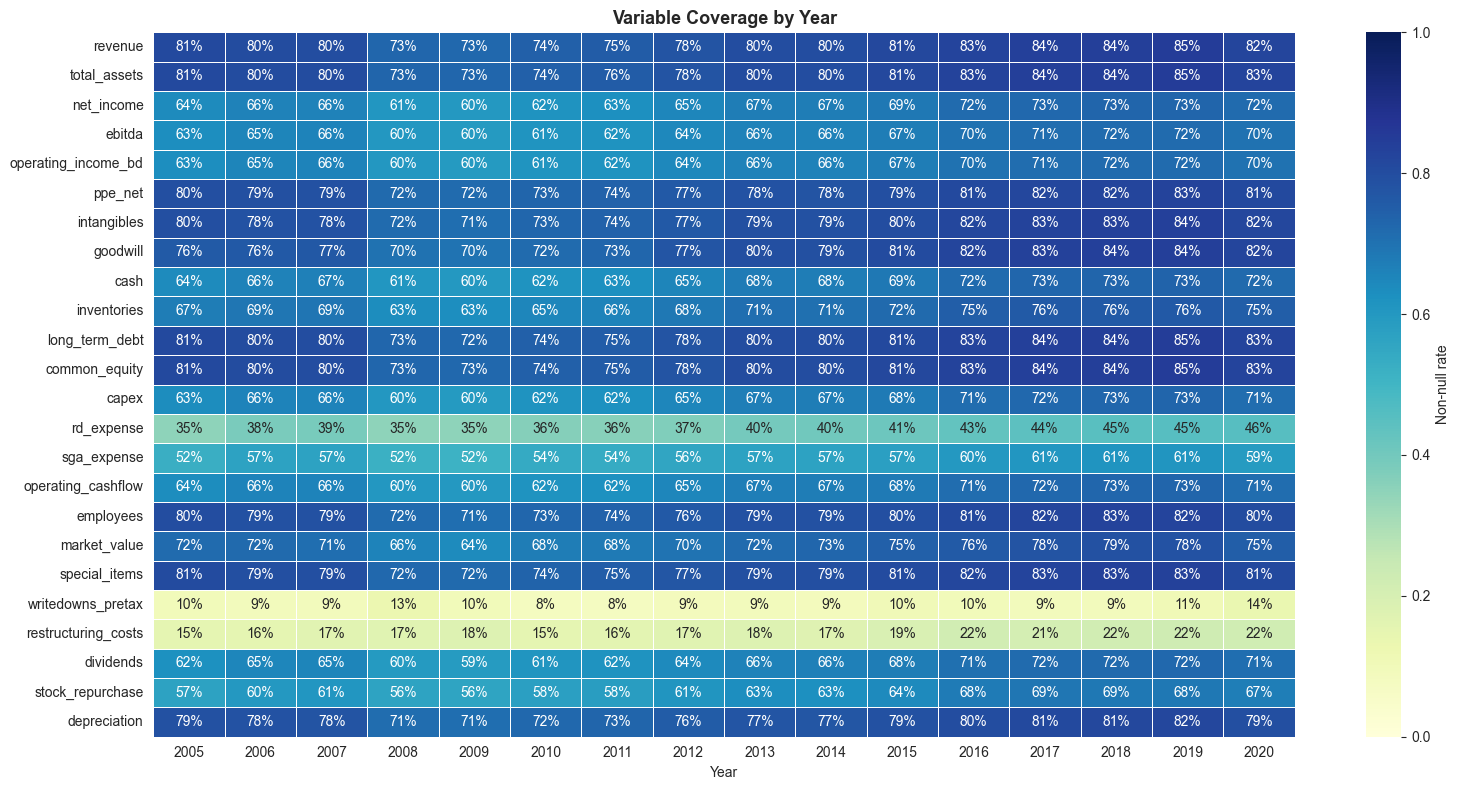

In [8]:
# Coverage heatmap: non-null rate by year for key variables
coverage_vars = [
    'revenue', 'total_assets', 'net_income', 'ebitda', 'operating_income_bd',
    'ppe_net', 'intangibles', 'goodwill', 'cash', 'inventories',
    'long_term_debt', 'common_equity', 'capex', 'rd_expense', 'sga_expense',
    'operating_cashflow', 'employees', 'market_value',
    'special_items', 'writedowns_pretax', 'restructuring_costs',
    'dividends', 'stock_repurchase', 'depreciation'
]
coverage_vars = [v for v in coverage_vars if v in df_financial.columns]

coverage = (
    df_financial.groupby('year')[coverage_vars]
    .apply(lambda g: g.notna().mean())
    .T
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    coverage, annot=True, fmt='.0%', cmap='YlGnBu',
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={'label': 'Non-null rate'}
)
ax.set_title('Variable Coverage by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [9]:
# Summary statistics for derived ratios and key levels
summary_vars = [
    'log_assets', 'log_revenue', 'leverage', 'roa',
    'asset_tangibility', 'rd_intensity', 'cash_ratio',
    'capex_intensity', 'intangibility', 'current_ratio',
    'gross_margin', 'operating_margin',
    'employees', 'market_value'
]
summary_vars = [v for v in summary_vars if v in df_financial.columns]

(
    df_financial[summary_vars]
    .describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
    .T
    .style.format('{:.3f}')
)

/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered i

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
log_assets,53557.000,6.153,2.527,0.000,0.000,2.720,4.594,6.403,7.874,9.140,11.601,15.006
log_revenue,53432.000,5.262,2.652,0.000,0.000,0.778,3.705,5.567,7.159,8.435,10.571,13.230
leverage,53442.000,inf,nan,0.000,0.035,0.186,0.362,0.591,0.850,0.972,16.892,inf
roa,44960.000,nan,nan,-inf,-17.068,-0.681,-0.148,0.012,0.059,0.113,0.383,inf
asset_tangibility,52337.000,0.196,0.241,0.000,0.000,0.004,0.021,0.091,0.276,0.619,0.900,1.000
rd_intensity,26660.000,inf,nan,-0.808,0.000,0.000,0.006,0.050,0.163,0.398,2.307,inf
cash_ratio,44979.000,0.234,0.265,-0.007,0.000,0.009,0.035,0.124,0.343,0.681,0.976,1.000
capex_intensity,44681.000,inf,nan,-0.926,0.000,0.001,0.008,0.023,0.051,0.095,0.323,inf
intangibility,52507.000,0.154,0.209,0.000,0.000,0.000,0.000,0.045,0.248,0.489,0.802,1.000
current_ratio,41887.000,inf,nan,0.000,0.012,0.611,1.144,1.899,3.281,6.187,26.420,inf


## Load SHELDUS Treatment Data

Build treatment assignments from SHELDUS climate events. Firms are considered treated when they experience a climate event above the damage threshold in a given year.

### Note

**Objective:** Build a city-level panel of climate events by mapping SHELDUS county-level data to firm production site cities.

## Data Challenge

SHELDUS records climate events at the **county FIPS** level, but firm locations are at the **city** level. To link climate exposure to firms, we need a city → county FIPS crosswalk.

## Geocoding Pipeline

```
Production Sites (city, state)
        │
        ▼
┌─────────────────────────┐
│ Google Maps Geocoding   │ → (latitude, longitude)
└───────────┬─────────────┘
            │
            ▼
┌─────────────────────────┐
│ FCC Census Block API    │ → county FIPS code
└───────────┬─────────────┘
            │
            ▼
City-FIPS Crosswalk
```

## SHELDUS Data Structure

| Field | Description |
|-------|-------------|
| `county_fips` | 5-digit FIPS code (state + county) |
| `year` | Year of climate event |
| `records` | Number of distinct events |
| `propertydmgadj_2020` | Property damage (2020 USD) |
| `cropdmgadj_2020` | Crop damage (2020 USD) |

## City-FIPS Crosswalk Schema

| Field | Description |
|-------|-------------|
| `city` | City name (normalized) |
| `state` | Full state name |
| `county_fips` | 5-digit FIPS code |
| `city_latitude` | Latitude coordinate |
| `city_longitude` | Longitude coordinate |

In [10]:
df_sheldus= pd.read_parquet(os.path.join(DATA_DIR, "df_sheldus.parquet"))

In [50]:
df_sheldus.head()

,state,state_abbr,city,year,records,cropdmgadj_2020,propertydmgadj_2020,city_latitude,city_longitude,population_2020,records_per_capita,cropdmgadj_2020_per_capita,propertydmgadj_2020_per_capita
7,Maryland,MD,Baltimore,2012,37.0,0.00,4080313.95,39.290502,-76.610407,6037624.0,0.000006,0.000000,0.675815
13,Maryland,MD,Baltimore,2018,9.0,0.00,3132091.03,39.290502,-76.610407,6037624.0,0.000001,0.000000,0.518762
16,Nevada,NV,Henderson,2005,5.0,0.00,798572.38,36.039525,-114.981721,3030281.0,0.000002,0.000000,0.263531
18,Nevada,NV,Henderson,2007,19.0,0.00,7850618.62,36.039525,-114.981721,3030281.0,0.000006,0.000000,2.590723
19,Nevada,NV,Henderson,2008,35.0,60872.27,1445107.66,36.039525,-114.981721,3030281.0,0.000012,0.020088,0.476889


### Treatment severity threshold

We filter SHELDUS events by keeping only those above a given percentile of the chosen damage variable. The current default is the **75th percentile of per-capita property damage** (`propertydmgadj_2020_per_capita`).

**Alternative damage variables:**
- `propertydmgadj_2020_per_capita` — property damage per capita, inflation-adjusted to 2020 USD (current choice).
- `cropdmgadj_2020` — crop damage in 2020 USD. More relevant for agricultural regions; may shift the geographic composition of treated cities toward rural counties.

**Threshold trade-off:**
- **Lower threshold** → more cities qualify as treated → more treated firms, but many will have few (or zero) pre-treatment years in the panel, reducing the effective sample for event-study estimation.
- **Higher threshold** → fewer treated cities → fewer treated firms, but each has a longer pre-treatment window, improving identification of pre-trends and dynamic effects.

The choice of variable and percentile can be changed in the cell below.

In [11]:
# Filter SHELDUS data
threshold = .75
var_event = "propertydmgadj_2020_per_capita"  # Property damage adjusted to 2020 dollars
threshold = df_sheldus[var_event].quantile(threshold)  # 50th percentile (median)

df_sheldus_filtered = df_sheldus[df_sheldus[var_event] >= threshold].copy()
print(f"✓ SHELDUS filtered: {len(df_sheldus_filtered):,} / {len(df_sheldus):,} events above threshold ({threshold*100_000:,.0f})")


✓ SHELDUS filtered: 87,581 / 350,240 events above threshold (11,961)


In [12]:
df_location = pd.read_parquet(os.path.join(DATA_DIR, "df_location.parquet"))

In [13]:
loc_viz = LocationVisualizer()

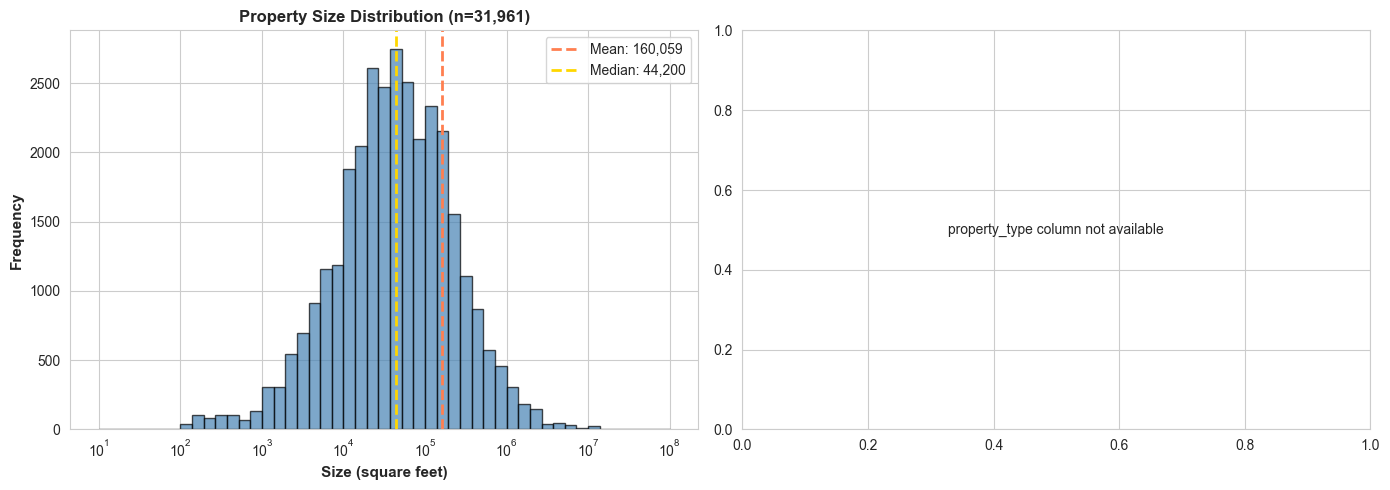

In [14]:
loc_viz.plot_property_size_distribution(df_location)
plt.show()

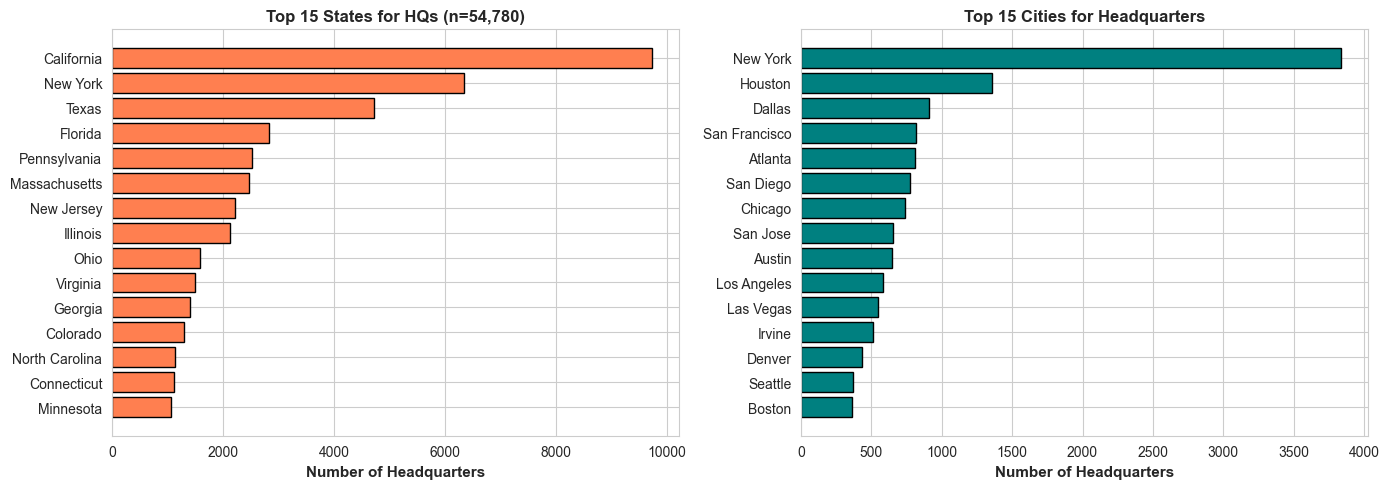

In [15]:
loc_viz.plot_headquarters_analysis(df_location)
plt.show()

### Treatment Variable Definitions

The `TreatmentAssigner` creates a firm-year panel linking firm locations to SHELDUS climate events. Each firm-year observation includes treatment indicators and sample quality flags.

**Treatment Indicators:**

| Variable | Description |
|----------|-------------|
| `has_event` | Binary indicator: 1 if the firm experienced a climate event above the damage threshold this year |
| `first_event_year` | Year of first treatment (NaN for never-treated firms) |

**Sample Quality Flags:**

| Variable | Description |
|----------|-------------|
| `no_city_match` | 1 if firm has no valid city data in any year (cannot match to SHELDUS, always never-treated) |
| `early_treated` | 1 if firm was treated in `study_start_year` (2005) — exclude from DiD as no pre-treatment period exists |
| `has_pre_data` | 1 if ever-treated firm has at least one observation before first treatment (`cnt_pre_years > 0`) |
| `has_post_data` | 1 if ever-treated firm has at least one observation after first treatment (`cnt_post_years > 0`) |
| `insufficient_pre` | 1 if ever-treated firm has fewer than `min_pre_years` pre-treatment years |
| `insufficient_post` | 1 if ever-treated firm has fewer than `min_post_years` post-treatment years |

**Counts:**

| Variable | Description |
|----------|-------------|
| `cnt_pre_years` | Number of years between first observation and first treatment (0 if treated in first observed year) |
| `cnt_post_years` | Number of years between first treatment and `study_end_year` or last observation |

**Categorical Summary:**

| Variable | Description |
|----------|-------------|
| `treatment_category` | Mutually exclusive firm-level classification: |

| Category | Definition |
|----------|------------|
| `never_treated` | Firm never experienced a climate event during the study period |
| `has_pre_post` | Ever-treated firm with at least one year of data before AND after first treatment |
| `has_pre_only` | Ever-treated firm with pre-treatment data but no post-treatment data |
| `has_post_only` | Ever-treated firm with post-treatment data but no pre-treatment data |
| `has_neither` | Ever-treated firm with neither pre nor post data (treated in only observed year) |

**Process:**

1. All (cik, year) combinations from `df_location` form the universe — firms are never dropped
2. Firms with valid city data are matched to SHELDUS events by (state, city, year)
3. Firms without city data receive `no_city_match=1` and `has_event=0` for all years (never-treated by definition)
4. Event indicators and sample quality flags are computed at the firm-year level

In [16]:
sheldus_builder = SheldusTreatmentBuilder(
    df_sheldus=df_sheldus_filtered,
    df_location=df_location,
    event_column=var_event,
)
df_matched = sheldus_builder.build()

# Step 2: Generic treatment assignment (did-panel-builder)
assigner = TreatmentAssigner(
    df_matched[["cik", "year", "has_event"]].copy(),
    config=config,
    study_start=2005,
    study_end=2020,
    min_pre_periods=1,
    min_post_periods=1,
)
df_treatment = assigner.build()

print(f"Treatment assignment:")
print(f"  Total firm-years: {len(df_treatment):,}")
print(f"  Unique firms: {df_treatment['cik'].nunique():,}")
print(f"  Treatment rate: {df_treatment['has_event'].mean():.2%}")


SheldusTreatmentBuilder initialized
  SHELDUS observations: 87,581
  Location observations: 54,780
  Event column: propertydmgadj_2020_per_capita
Matched firm-event data built
  All unique firms: 11,014
    - With valid city data: 11,010
    - Without city data (never-treated): 4
  Firm-years: 51,336
  Unique firms in panel: 11,014
Treatment assignment:
  Total firm-years: 51,336
  Unique firms: 11,014
  Treatment rate: 33.80%


In [17]:
df_treatment.head()

,cik,year,has_event,first_event_time,cnt_pre_periods,cnt_post_periods,early_treated,insufficient_pre,insufficient_post,has_pre_data,has_post_data,treatment_category
0,1385187,2013,True,2011,0,3,0,1,0,0,1,has_post_only
1,1522727,2014,False,2013,1,5,0,0,0,1,1,has_pre_post
2,1096199,2006,True,2006,0,3,0,1,0,0,1,has_post_only
3,33185,2016,False,2006,0,9,0,1,0,0,1,has_post_only
4,1464963,2014,True,2010,0,10,0,1,0,0,1,has_post_only


In [18]:
# --- NEW: TreatmentAssigner summary ---
assigner.summary()


,treatment_category,n_units,pct_units
0,never_treated,3992,36.2
1,has_pre_post,2195,19.9
2,has_pre_only,741,6.7
3,has_post_only,3148,28.6
4,has_neither,938,8.5


In [19]:
# --- NEW: TreatmentAssigner filter ---
df_treatment = assigner.filter(
    drop_early_treated=True,
    keep_categories=["never_treated", "has_pre_post"],
)

print(f"After filter: {df_treatment['cik'].nunique():,} firms, {len(df_treatment):,} obs")


After filter: 6,187 firms, 27,889 obs


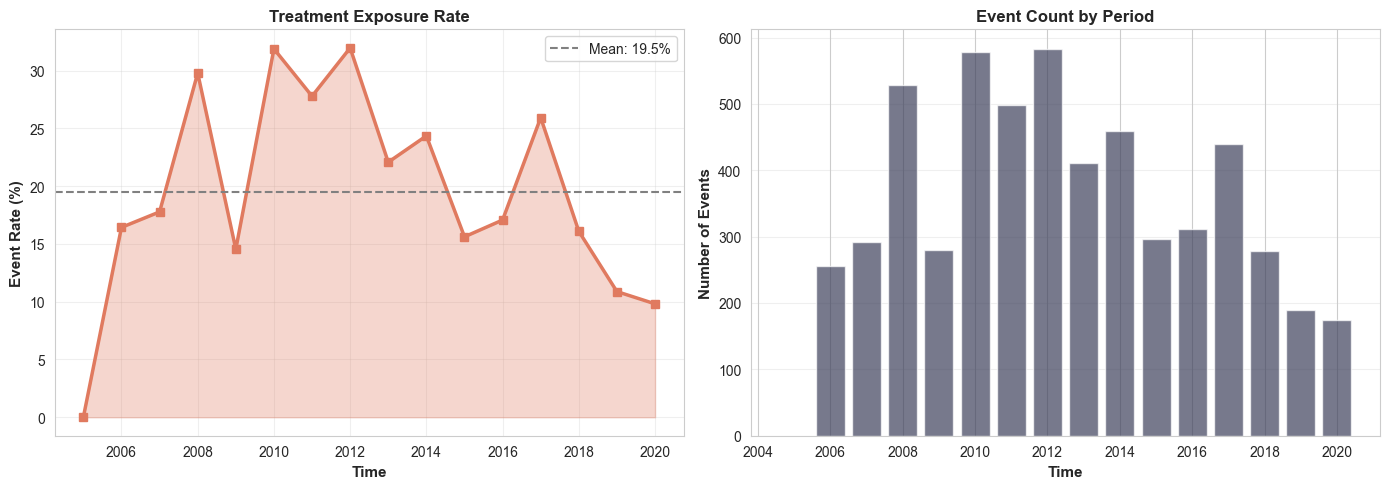

In [20]:
# --- NEW: did-panel-builder ---
plot_treatment_summary(df_treatment, unit_col="cik", time_col="year", time_range=(2005, 2020));


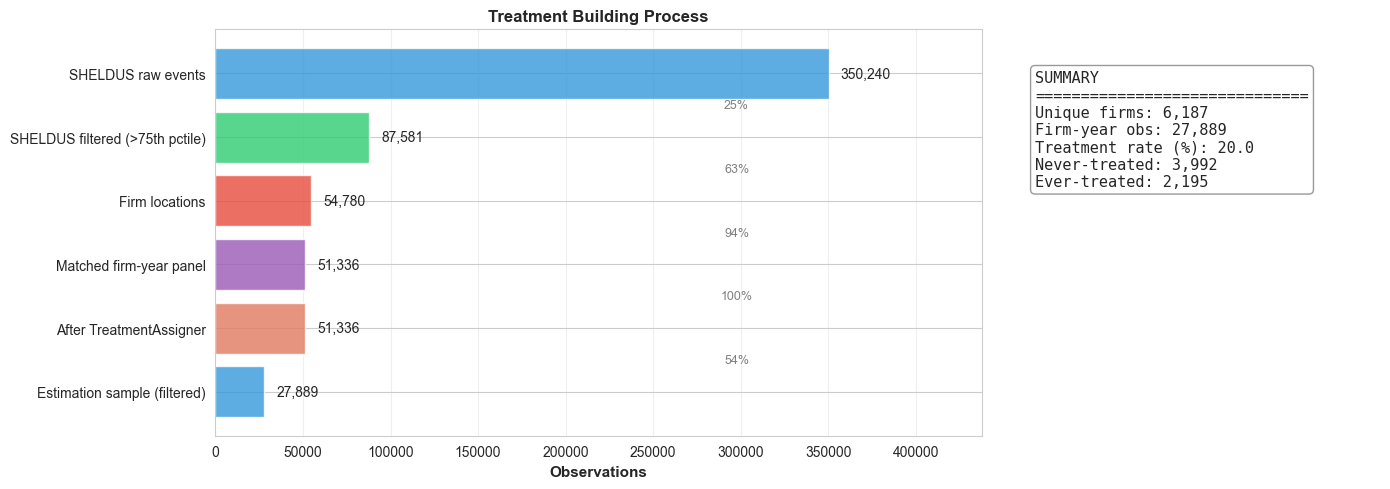

In [21]:
# --- NEW: did-panel-builder ---
funnel_steps = [
    ("SHELDUS raw events", len(df_sheldus)),
    ("SHELDUS filtered (>75th pctile)", len(df_sheldus_filtered)),
    ("Firm locations", len(df_location)),
    ("Matched firm-year panel", len(df_matched)),
    ("After TreatmentAssigner", len(assigner.build())),
    ("Estimation sample (filtered)", len(df_treatment)),
]

summary_stats = {
    "Unique firms": df_treatment["cik"].nunique(),
    "Firm-year obs": len(df_treatment),
    "Treatment rate (%)": df_treatment["has_event"].mean() * 100,
    "Never-treated": int((df_treatment.drop_duplicates("cik")["treatment_category"] == "never_treated").sum()),
    "Ever-treated": int((df_treatment.drop_duplicates("cik")["treatment_category"] != "never_treated").sum()),
}

plot_treatment_funnel(funnel_steps, summary_stats=summary_stats);


In [22]:
# Load US states shapefile for mapping
import geopandas as gpd

url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"
states = gpd.read_file(url)

# Filter to CONUS (exclude Alaska, Hawaii, territories)
exclude = ['AK', 'HI', 'PR', 'VI', 'GU', 'AS', 'MP']
conus_states = states[~states['STUSPS'].isin(exclude)]

print(f"✓ Loaded CONUS states: {len(conus_states)} states")

✓ Loaded CONUS states: 49 states


In [23]:
# --- NEW: Replicate location-event matching manually ---
df_loc_filtered = df_location
df_loc_filtered = df_loc_filtered.copy()
df_loc_filtered["year"] = df_loc_filtered["year"].astype(str)
df_loc_filtered["cik"] = df_loc_filtered["cik"].astype(str)

sheldus_coords = (
    df_sheldus_filtered[["state", "city", "year", "city_latitude", "city_longitude",
                         var_event]]
    .drop_duplicates(subset=["state", "city", "year"])
)

df_with_city = df_loc_filtered.dropna(subset=["state", "city"])
df_location_events = df_with_city.merge(
    sheldus_coords, on=["state", "city", "year"], how="left",
)
df_location_events[var_event] = df_location_events[var_event].fillna(0)
df_location_events["has_event"] = (df_location_events[var_event] > 0).astype(int)

# Fill missing coordinates from SHELDUS city lookup
coord_lookup = (
    df_sheldus_filtered[["state", "city", "city_latitude", "city_longitude"]]
    .drop_duplicates(subset=["state", "city"])
    .rename(columns={"city_latitude": "lat_fill", "city_longitude": "lon_fill"})
)
df_location_events = df_location_events.merge(coord_lookup, on=["state", "city"], how="left")
df_location_events["city_latitude"] = df_location_events["city_latitude"].fillna(df_location_events["lat_fill"])
df_location_events["city_longitude"] = df_location_events["city_longitude"].fillna(df_location_events["lon_fill"])
df_location_events = df_location_events.drop(columns=["lat_fill", "lon_fill"])
df_location_events["year"] = pd.to_numeric(df_location_events["year"])

print(f"Firm location events: {len(df_location_events):,}")
print(f"  With climate event: {df_location_events['has_event'].sum():,}")
print(f"  Without event: {(df_location_events['has_event'] == 0).sum():,}")
print(f"  With coordinates: {df_location_events['city_latitude'].notna().sum():,}")


Firm location events: 54,769
  With climate event: 18,142
  Without event: 36,627
  With coordinates: 53,048


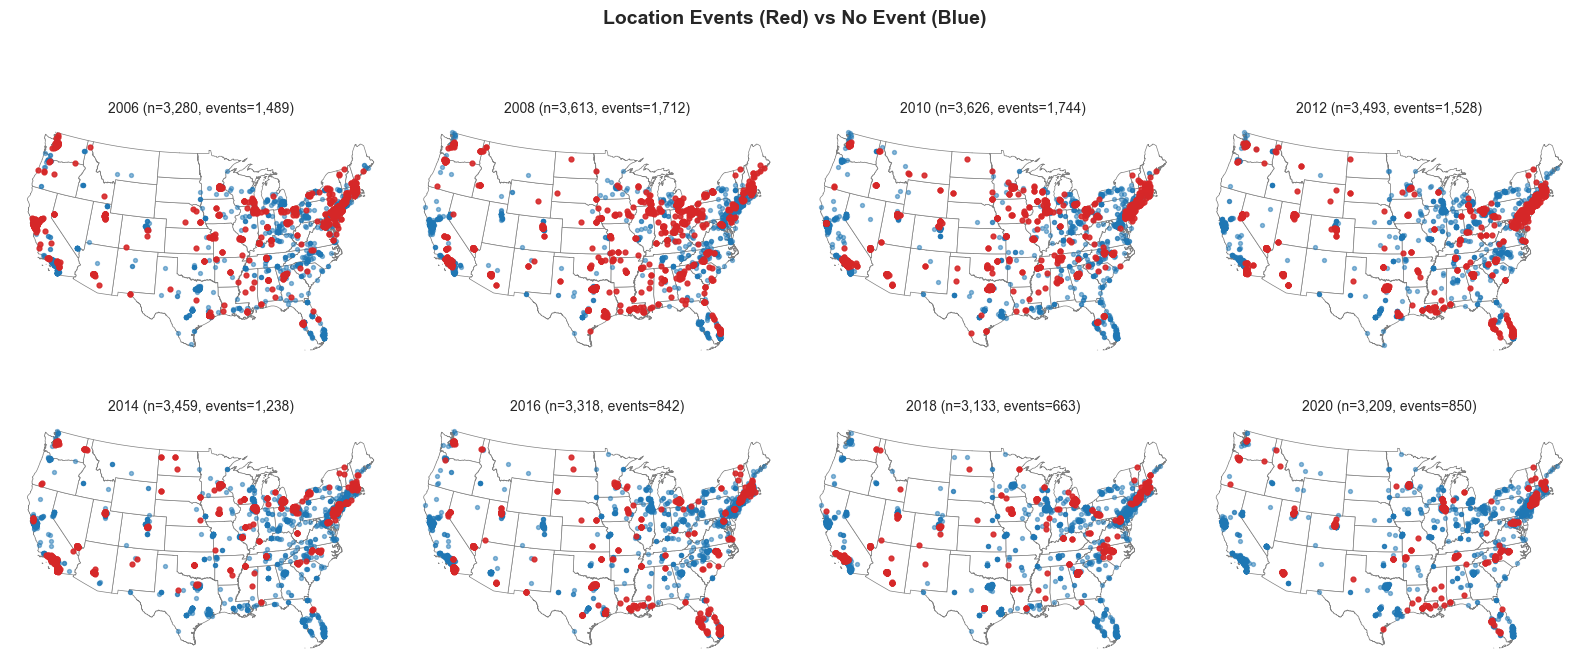

In [24]:
# --- NEW: did-panel-builder ---
plot_location_events(
    df_location_events,
    lat_col="city_latitude",
    lon_col="city_longitude",
    time_col="year",
    time_periods=[2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020],
    boundaries=conus_states,
);


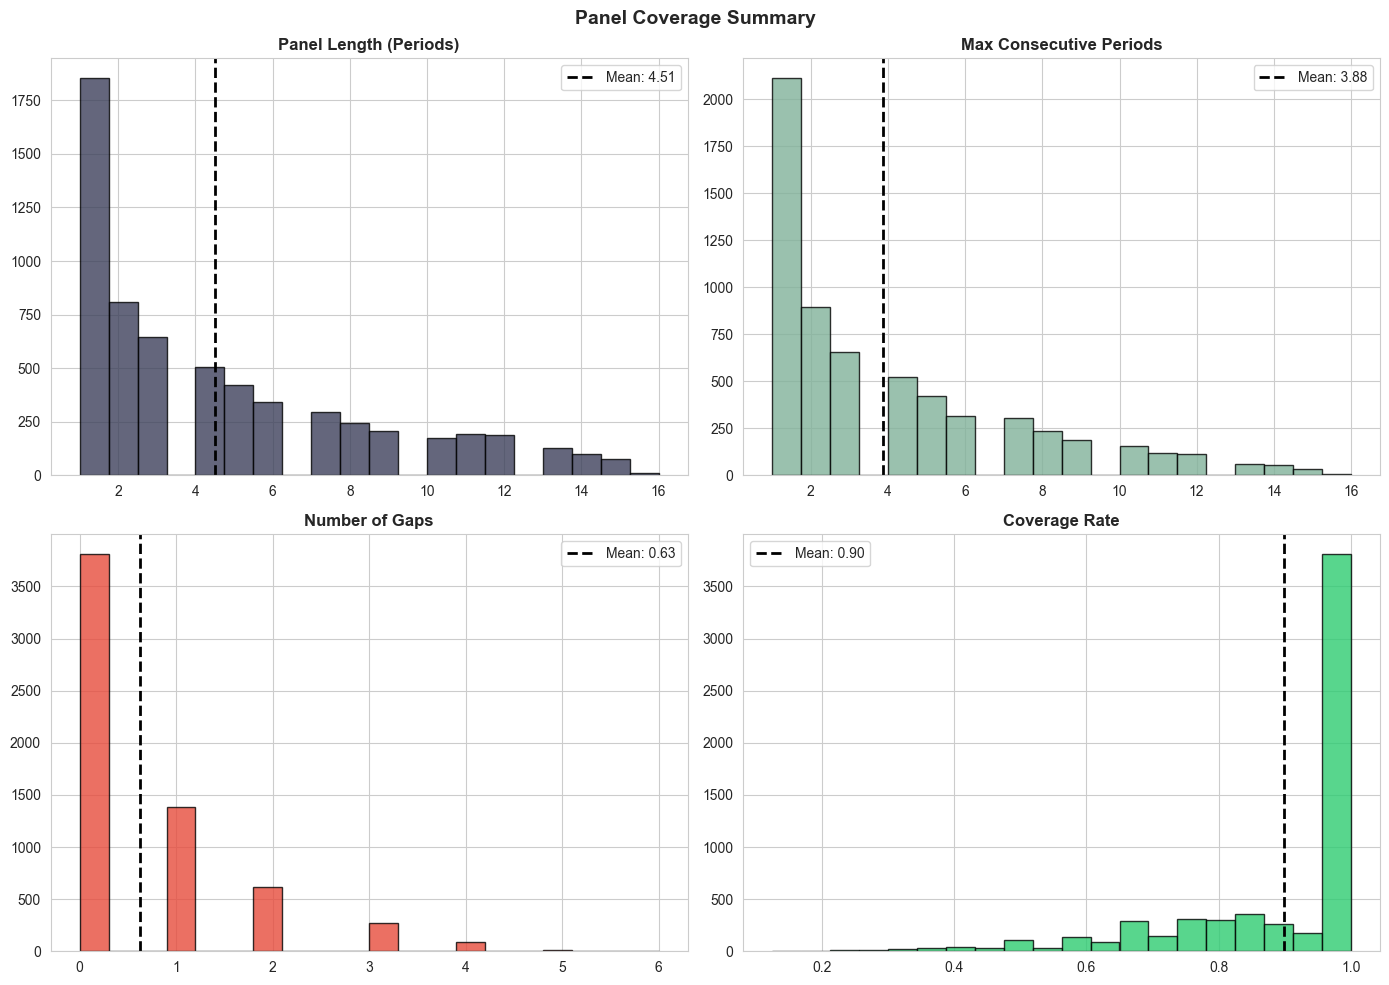

In [25]:
# --- NEW: did-panel-builder ---
plot_coverage_summary(df_treatment, unit_col="cik", time_col="year");


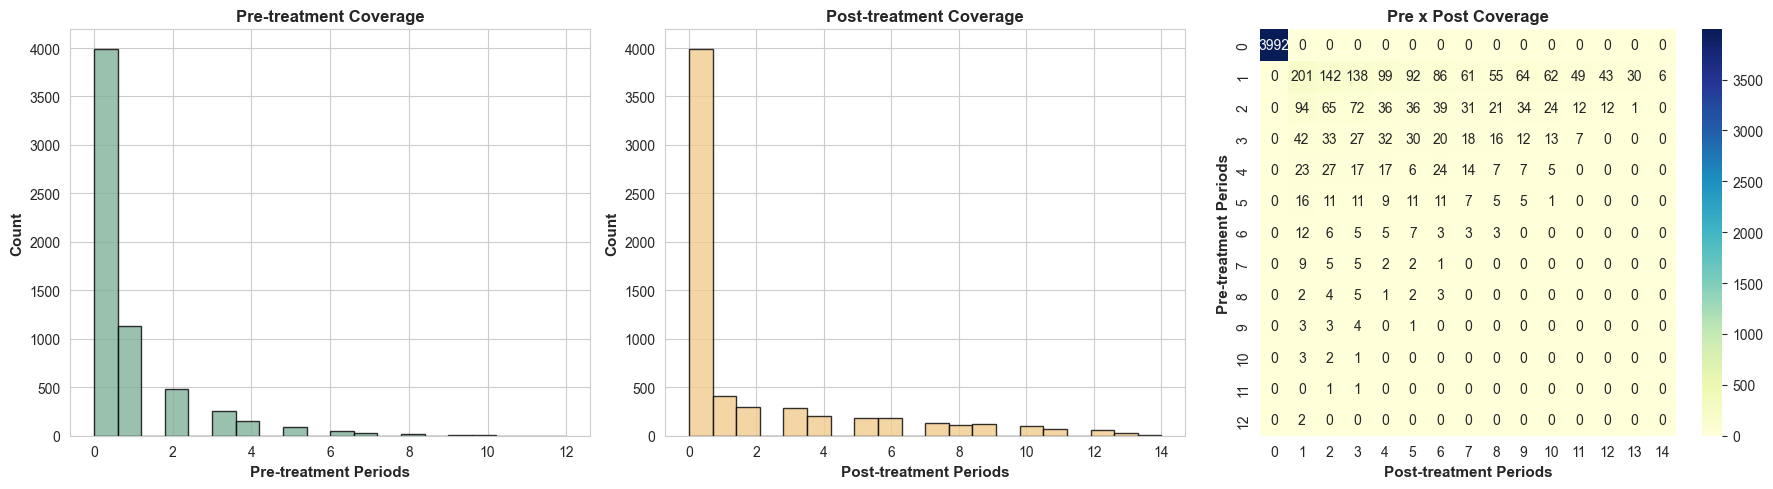

In [26]:
# --- NEW: did-panel-builder ---
plot_pre_post_coverage(df_treatment, unit_col="cik");


In [27]:
# --- NEW: did-panel-builder ---
CoverageAnalyzer(config).summary(df_treatment)


,n_periods_mean,n_periods_median,n_periods_min,n_periods_max,time_span_mean,time_span_median,time_span_min,time_span_max,n_consecutive_mean,n_consecutive_median,n_consecutive_min,n_consecutive_max,n_gaps_mean,n_gaps_median,n_gaps_min,n_gaps_max,coverage_rate_mean,coverage_rate_median,coverage_rate_min,coverage_rate_max,n_units,n_balanced,pct_balanced
0,4.507677,3.0,1.0,16.0,5.462744,4.0,1.0,16.0,3.881687,3.0,1.0,16.0,0.62599,0.0,0.0,6.0,0.898248,1.0,0.125,1.0,6187,3808,61.5


## 1. Multi-Event Panel (de Chaisemartin)

Firms can experience multiple climate events. Each event contributes to the treatment intensity.

In [28]:
# --- NEW: did-panel-builder.MultiEventPanel ---
panel_multi = MultiEventPanel(df_treatment, config=config)
df_multi = panel_multi.build()

print(f"MultiEventPanel: {df_multi.shape}")
print(f"Treatment type distribution:")
print(df_multi['treatment_type'].value_counts())
print(f"\nD column (binary absorbing treatment):")
print(f"  D=0: {(df_multi['D'] == 0).sum():,}  D=1: {(df_multi['D'] == 1).sum():,}")


MultiEventPanel: (27889, 19)
Treatment type distribution:
treatment_type
treated          17384
never_treated    10505
Name: count, dtype: int64

D column (binary absorbing treatment):
  D=0: 15,133  D=1: 12,756


In [29]:
df_multi = (
    df_multi
    .merge(df_industry, how = 'left', on='cik')
    .merge(df_financial.drop(columns = ["period_end_date"]), on=["cik", "year"], how="left")
)

print(f"df_multi shape: {df_multi.shape}")

df_multi shape: (28102, 86)


## 2. Staggered Panel (Sun & Abraham)

Uses first treatment timing. Not-yet-treated firms serve as controls.

In [30]:
# --- NEW: did-panel-builder.StaggeredPanel ---
panel_stag = StaggeredPanel(df_treatment, config=config)
df_staggered = panel_stag.build()

print(f"StaggeredPanel: {df_staggered.shape}")
print(f"Treatment type distribution:")
print(df_staggered['treatment_type'].value_counts())


StaggeredPanel: (27889, 17)
Treatment type distribution:
treatment_type
treated          17384
never_treated    10505
Name: count, dtype: int64


In [31]:
df_sun = panel_stag.filter_sample(
    keep_treatment_types=["treated", "never_treated"],
    min_event_time=-3,
    max_event_time=5,
    min_pre_periods=1,
    min_post_periods=2,
)


In [32]:
df_staggered = (
    df_sun
    .merge(df_industry, how = 'left', on='cik')
    .merge(df_financial.drop(columns = ["period_end_date"]), on=["cik", "year"], how="left")
)

print(f"df_staggered shape: {df_staggered.shape}")

df_staggered shape: (21567, 84)


### 3. Stacked Cohort Panel (Roth et al.)

Creates cohort-specific datasets with clean 2×2 comparisons.

In [33]:
# --- NEW: did-panel-builder.StackedPanel ---
panel_stack = StackedPanel(
    df_treatment,
    config=config,
    time_pre=3,
    time_post=3,
    cohort_times=list(range(2008, 2018)),
)
df_stacked = panel_stack.build()

print(f"StackedPanel: {df_stacked.shape}")


StackedPanel: (85766, 21)


In [34]:
df_stacked = (
    df_stacked
    .merge(df_industry, how = 'left', on='cik')
    .merge(df_financial.drop(columns = ["period_end_date"]), on=["cik", "year"], how="left")
)

print(f"df_stacked shape: {df_stacked.shape}")

df_stacked shape: (86546, 88)


In [35]:
# Summary of cohorts
cohort_summary = panel_stack.summary()
cohort_summary

,n_obs,n_units,time_min,time_max
0,85766,6187,2005,2020


In [36]:
panel_stack.cohort_summary()   # per-cohort breakdown

,n_firms,n_treated_obs,event_window,n_treated_units
cohort,,,,
2008,2831,1649,"[-3, 3]",334
2009,2431,505,"[-3, 3]",100
2010,2729,1239,"[-3, 3]",251
2011,2790,706,"[-3, 3]",147
2012,3140,970,"[-3, 3]",202
2013,2969,437,"[-3, 3]",95
2014,3061,655,"[-3, 3]",138
2015,3049,347,"[-3, 3]",78
2016,3231,275,"[-3, 3]",59


## 4. Visualization

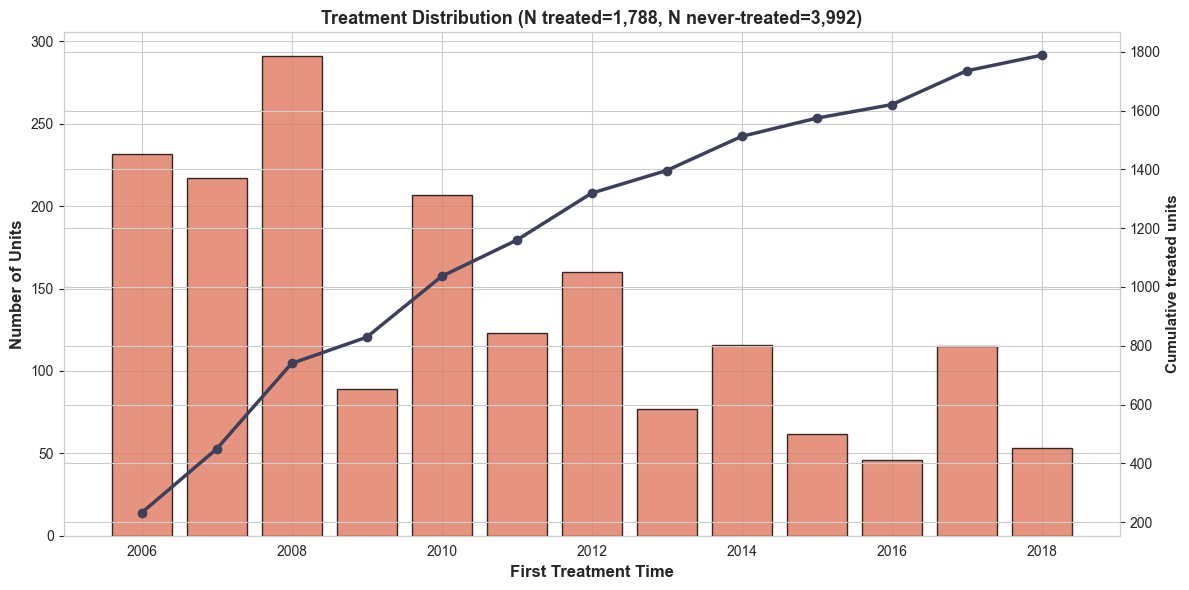

In [37]:
# --- NEW: did-panel-builder ---
plot_treatment_distribution(df_staggered, unit_col="cik");


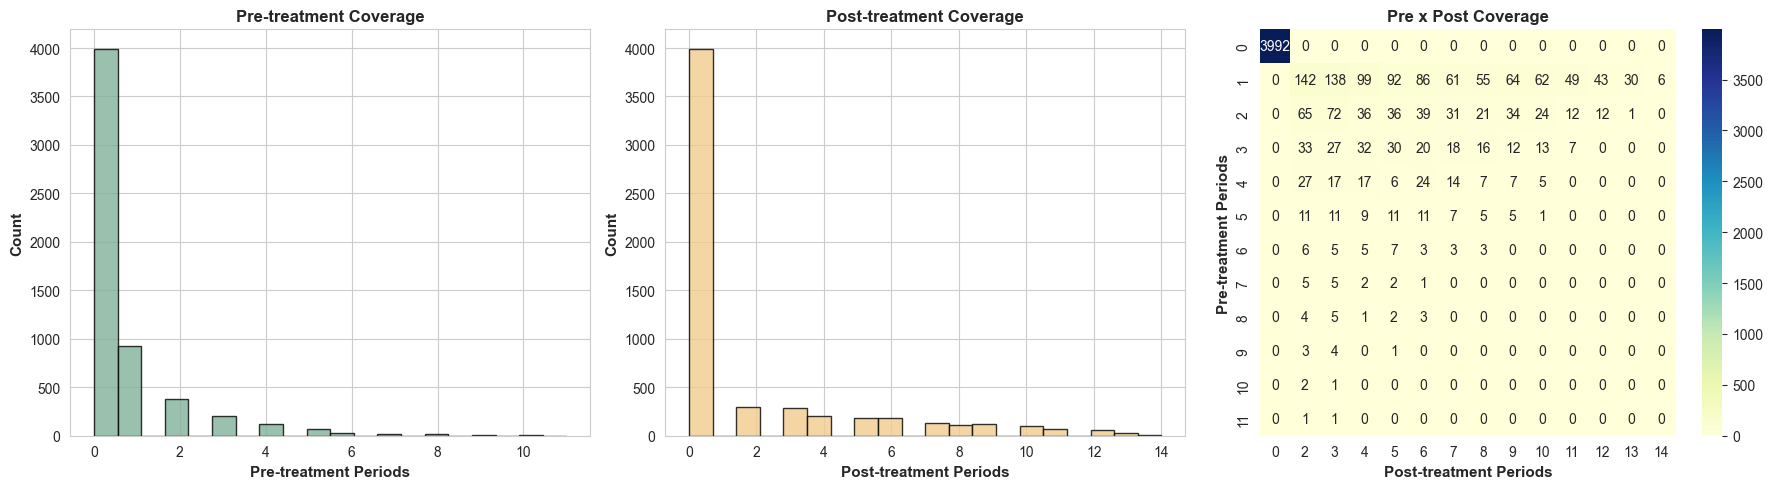

In [38]:
# --- NEW: did-panel-builder ---
plot_pre_post_coverage(df_staggered, unit_col="cik");


In [39]:
# --- NEW: did-panel-builder ---
panel_stag.summary()


,n_obs,n_units,time_min,time_max,n_never_treated,n_treated
0,27889,6187,2005,2020,3992,2195


### Event Study Plots

After merging outcomes, visualize the treatment effect dynamics.

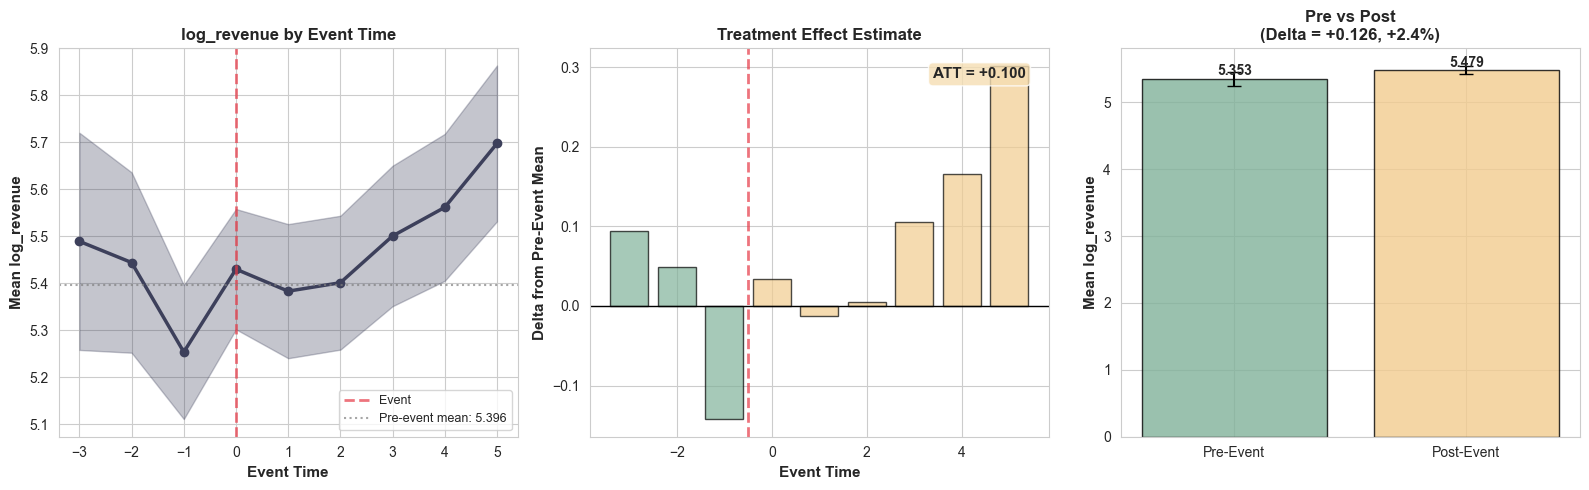

In [40]:
# --- NEW: did-panel-builder ---
plot_by_treatment_status(
    df_staggered,
    outcome="log_revenue",
    event_time_col="event_time",
    treatment_status_col="treatment_status",
);


/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/did_panel_builder/visualization/event_study.py:371: RuntimeWarning: invalid value encountered in scalar divide
  att_pct = (att / pre_mean * 100) if pre_mean != 0 else 0


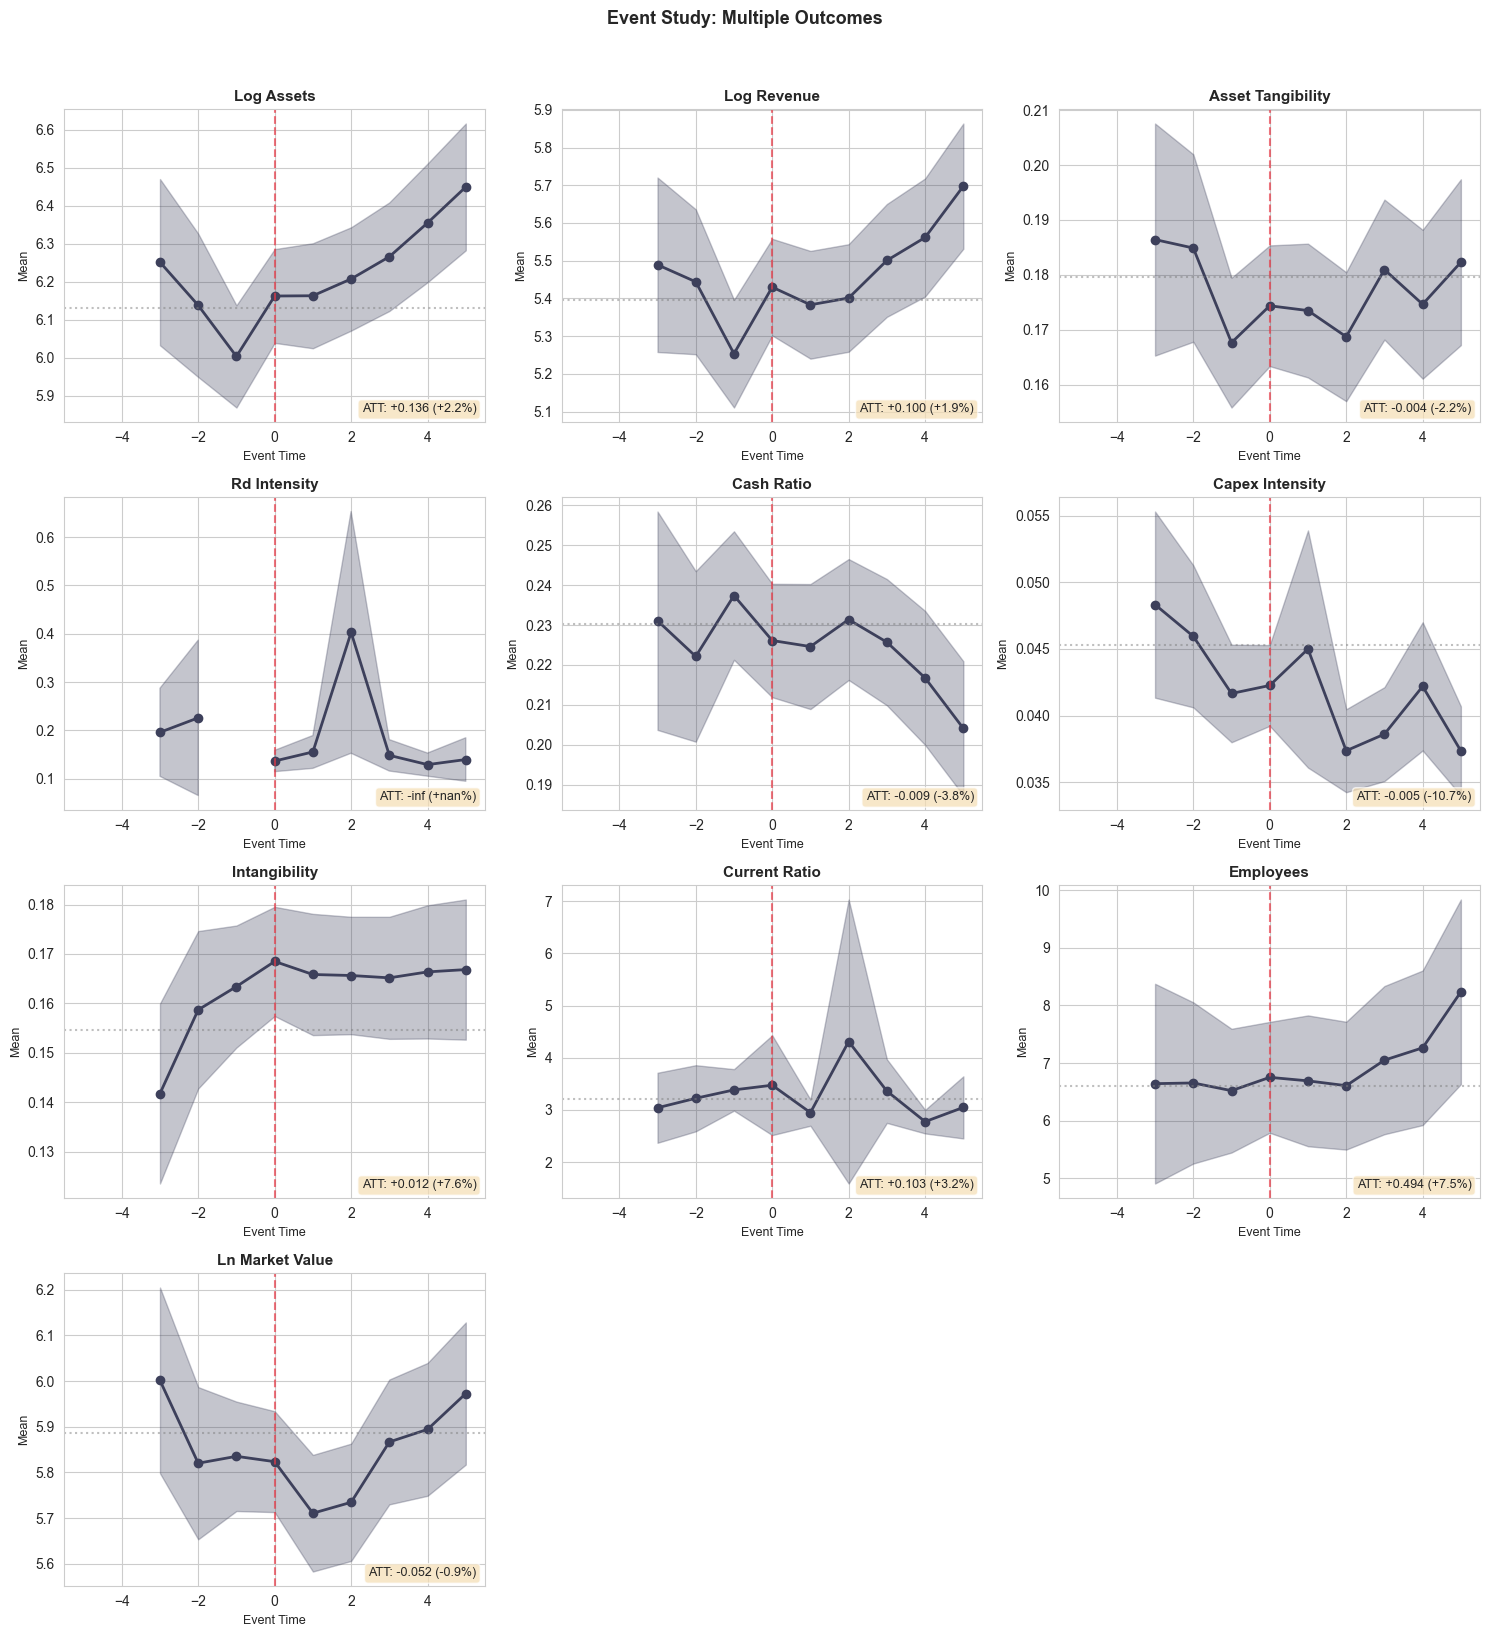

In [41]:
# --- NEW: did-panel-builder ---
outcomes =  [
    'log_assets', 'log_revenue',
    'asset_tangibility', 'rd_intensity', 'cash_ratio',
    'capex_intensity', 'intangibility', 'current_ratio',
    'employees', 'ln_market_value'
]

plot_multi_outcome(
    df_staggered,
    outcomes=outcomes,
    event_time_col="event_time",
    treatment_status_col="treatment_status",
);


In [42]:
# --- NEW: did-panel-builder PrePostDiagnostics ---
diag = PrePostDiagnostics(config=config)
diag_results = diag.analyze(
    df_staggered,
    outcomes=[
    'log_assets', 'log_revenue',
    'asset_tangibility', 'rd_intensity', 'cash_ratio',
    'capex_intensity', 'intangibility', 'current_ratio',
    'employees', 'ln_market_value'
],
    treatment_col="treatment_type",
    event_time_col="event_time",
    selection_outcome="log_revenue",
)
diag.print_summary(diag_results)


Pre/post means (treated units)
  Outcome                 Pre      Post      Diff    Pre N   Post N
  -----------------------------------------------------------------
  log_assets           6.0887    6.2491   +0.1603    2,239    6,643
  log_revenue          5.3528    5.4790   +0.1261    2,233    6,634
  asset_tangibility    0.1762    0.1752   -0.0009    2,208    6,553
  rd_intensity            inf    0.1892      -inf    1,088    3,339
  cash_ratio           0.2319    0.2228   -0.0091    1,842    5,500
  capex_intensity      0.0441    0.0407   -0.0035    1,836    5,483
  intangibility        0.1580    0.1665   +0.0085    2,200    6,548
  current_ratio        3.2746    3.3647   +0.0901    1,738    5,189
  employees            6.5831    7.0164   +0.4333    2,192    6,538
  ln_market_value      5.8624    5.8226   -0.0398    2,032    6,165

Within-unit variation (treated units)
  Outcome             Units   Always 0   Always 1   Varies   % Varies
  ------------------------------------------

/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


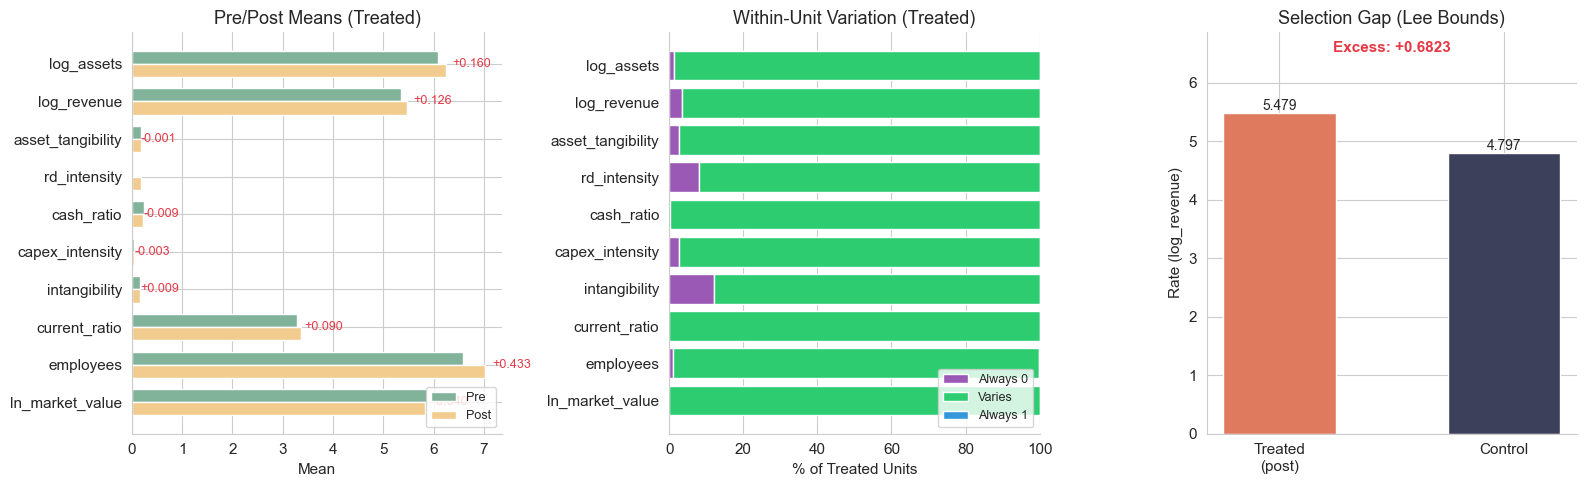

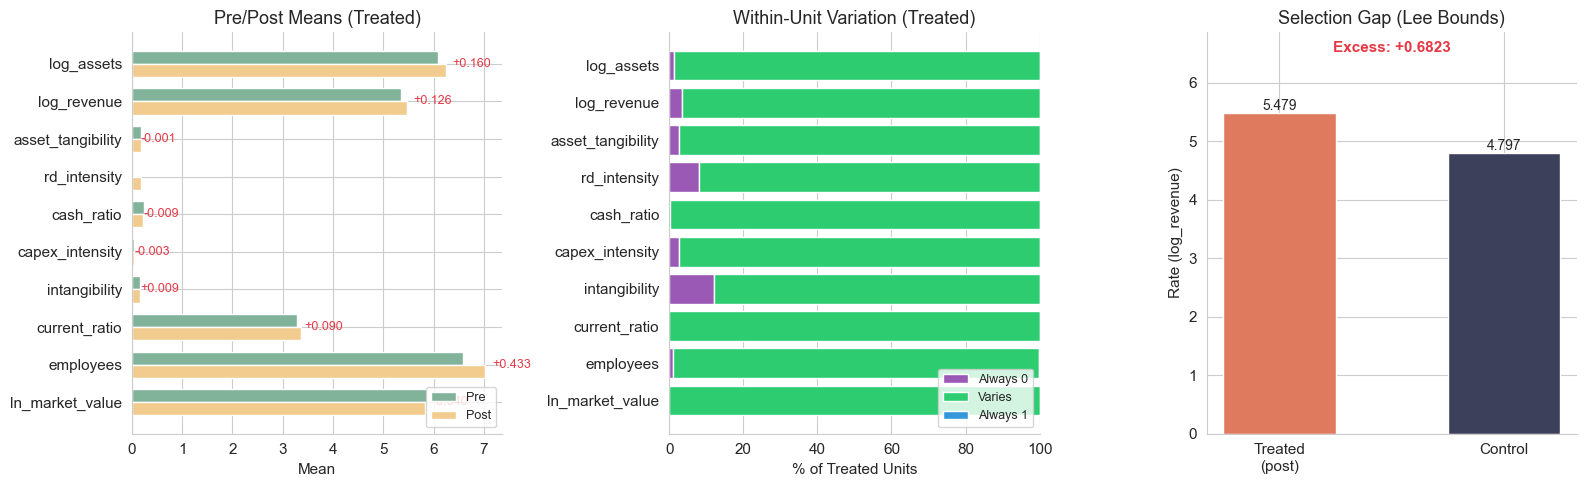

In [43]:
# Visual diagnostic summary
diag.plot_summary(diag_results)


In [44]:
# Pre/post means for treated firms (raw comparison, not causal)
df_prepost = diag_results['pre_post_means']
df_prepost.style.format({
    'pre_mean': '{:.4f}', 'post_mean': '{:.4f}', 'diff': '{:+.4f}',
    'pre_obs': '{:,.0f}', 'post_obs': '{:,.0f}'
}).bar(subset=['diff'], align='zero', color=['#d65f5f', '#5fba7d'])

/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/io/formats/style.py:4460: RuntimeWarning: invalid value encountered in scalar divide
  start, end = z_frac, (x - left) / (right - left)
/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/io/formats/style.py:4458: RuntimeWarning: invalid value encountered in scalar divide
  start, end = (x - left) / (right - left), z_frac
/Users/thomas/anaconda3/envs/research_and_analytics/lib/python3.11/site-packages/pandas/io/formats/style.py:4458: RuntimeWarning: invalid value encountered in scalar subtract
  start, end = (x - left) / (right - left), z_frac


,outcome,pre_mean,post_mean,diff,pre_obs,post_obs
0,log_assets,6.0887,6.2491,+0.1603,"2,239","6,643"
1,log_revenue,5.3528,5.4790,+0.1261,"2,233","6,634"
2,asset_tangibility,0.1762,0.1752,-0.0009,"2,208","6,553"
3,rd_intensity,inf,0.1892,-inf,"1,088","3,339"
4,cash_ratio,0.2319,0.2228,-0.0091,"1,842","5,500"
5,capex_intensity,0.0441,0.0407,-0.0035,"1,836","5,483"
6,intangibility,0.1580,0.1665,+0.0085,"2,200","6,548"
7,current_ratio,3.2746,3.3647,+0.0901,"1,738","5,189"
8,employees,6.5831,7.0164,+0.4333,"2,192","6,538"
9,ln_market_value,5.8624,5.8226,-0.0398,"2,032","6,165"


## 6. Export for Regression

Export the final panel for diff-in-diff estimation.

In [45]:
# Export panels for regression

df_treatment.to_parquet(f"{DATA_DIR}/example_treatment.parquet", index=False)
df_multi.to_parquet(f"{DATA_DIR}/example_did_multi_event.parquet", index=False)
df_staggered.to_parquet(f"{DATA_DIR}/example_did_staggered.parquet", index=False)
df_stacked.to_parquet(f"{DATA_DIR}/example_did_stacked.parquet", index=False)

print(f"✓ Exported panels to {DATA_DIR}/")
print(f"  Multi-event:  {len(df_multi):,} rows  ({df_multi['cik'].nunique():,} firms)")
print(f"  Staggered:    {len(df_staggered):,} rows  ({df_staggered['cik'].nunique():,} firms)")
print(f"  Stacked:      {len(df_stacked):,} rows  ({df_stacked['cik'].nunique():,} firms)")

✓ Exported panels to /Users/thomas/Projects/research_projects/did-cik-performance-climate-event/data/
  Multi-event:  28,102 rows  (6,187 firms)
  Staggered:    21,567 rows  (5,780 firms)
  Stacked:      86,546 rows  (6,187 firms)
